In [1]:
import numpy as np
import pandas as pd

# 正态分布的概率密度函数
def normal_distribution(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

# 生成从 -3.0 到 3.0 的均匀采样 21 个点
x_values = np.linspace(-3.0, 3.0, 21)

# 计算原始正态分布值
y_values = normal_distribution(x_values)

# 放大因子
scaling_factor = 5 / normal_distribution(0)

# 计算放大后的值
y_scaled = y_values * scaling_factor

# 创建 DataFrame 并打印结果
df = pd.DataFrame({'X': x_values, 'Y (Scaled)': y_scaled})
print(df)

      X  Y (Scaled)
0  -3.0    0.055545
1  -2.7    0.130607
2  -2.4    0.280674
3  -2.1    0.551253
4  -1.8    0.989493
5  -1.5    1.623262
6  -1.2    2.433761
7  -0.9    3.334884
8  -0.6    4.176351
9  -0.3    4.779987
10  0.0    5.000000
11  0.3    4.779987
12  0.6    4.176351
13  0.9    3.334884
14  1.2    2.433761
15  1.5    1.623262
16  1.8    0.989493
17  2.1    0.551253
18  2.4    0.280674
19  2.7    0.130607
20  3.0    0.055545


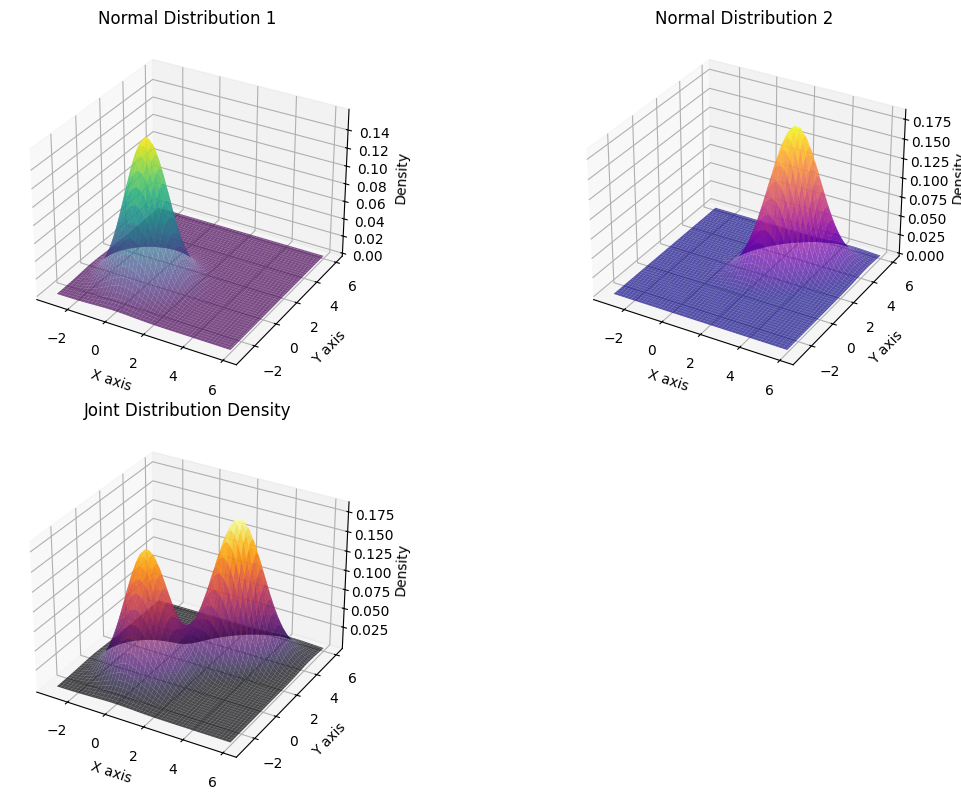

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 定义两个正态分布的参数
mean1 = [0, 0]  # 第一组的均值
cov1 = [[1, 0], [0, 1]]  # 第一组的协方差矩阵

mean2 = [3, 3]  # 第二组的均值
cov2 = [[1, 0.5], [0.5, 1]]  # 第二组的协方差矩阵

# 定义网格范围
x = np.linspace(-3, 6, 100)
y = np.linspace(-3, 6, 100)
X, Y = np.meshgrid(x, y)

# 计算两个正态分布的概率密度
Z1 = multivariate_normal.pdf(np.dstack((X, Y)), mean=mean1, cov=cov1)
Z2 = multivariate_normal.pdf(np.dstack((X, Y)), mean=mean2, cov=cov2)

# 计算联合分布
Z_joint = Z1 + Z2

# 绘制两个正态分布的曲线和联合分布密度图
fig = plt.figure(figsize=(12, 8))

# 绘制第一个正态分布
ax1 = fig.add_subplot(221, projection='3d')
ax1.plot_surface(X, Y, Z1, cmap='viridis', alpha=0.7)
ax1.set_title('Normal Distribution 1')
ax1.set_xlabel('X axis')
ax1.set_ylabel('Y axis')
ax1.set_zlabel('Density')

# 绘制第二个正态分布
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_surface(X, Y, Z2, cmap='plasma', alpha=0.7)
ax2.set_title('Normal Distribution 2')
ax2.set_xlabel('X axis')
ax2.set_ylabel('Y axis')
ax2.set_zlabel('Density')

# 绘制联合分布密度图
ax3 = fig.add_subplot(223, projection='3d')
ax3.plot_surface(X, Y, Z_joint, cmap='inferno', alpha=0.7)
ax3.set_title('Joint Distribution Density')
ax3.set_xlabel('X axis')
ax3.set_ylabel('Y axis')
ax3.set_zlabel('Density')

plt.tight_layout()
plt.show()

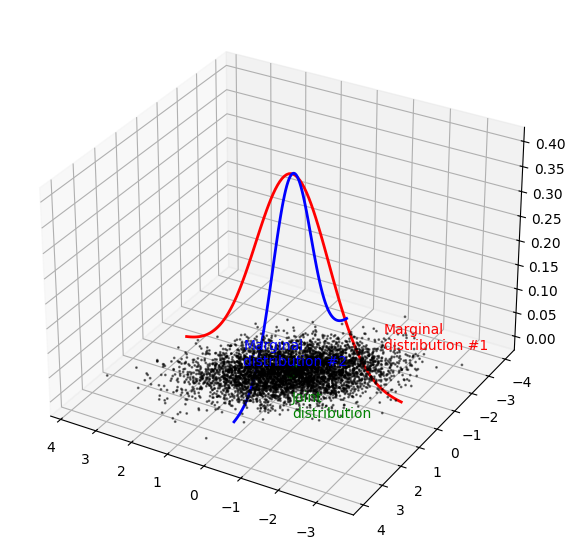

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

# 创建数据
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]
x, y = np.random.multivariate_normal(mean, cov, 5000).T

# 创建边缘分布数据
x_marginal = np.linspace(-3, 3, 100)
y_marginal = np.linspace(-3, 3, 100)
x_pdf = multivariate_normal.pdf(x_marginal, mean=0, cov=1)
y_pdf = multivariate_normal.pdf(y_marginal, mean=0, cov=1)

# 创建图形
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 绘制联合分布散点图
ax.scatter(x, y, np.zeros_like(x), color='black', s=1, alpha=0.5)

# 绘制边缘分布
ax.plot(x_marginal, np.zeros_like(x_marginal), x_pdf, color='red', lw=2)
ax.plot(np.zeros_like(y_marginal), y_marginal, y_pdf, color='blue', lw=2)

# 设置标签
ax.text(-2.5, 0, 0.1, 'Marginal\ndistribution #1', color='red', fontsize=10)
ax.text(0, 2.5, 0.1, 'Marginal\ndistribution #2', color='blue', fontsize=10)
ax.text(0, 0, -0.1, 'Joint\ndistribution', color='green', fontsize=10)

# 绘制联合分布的椭圆
ax.plot([0], [0], [0], 'o', markersize=10, color='green')

# 调整视角
ax.view_init(30, 120)

plt.show()

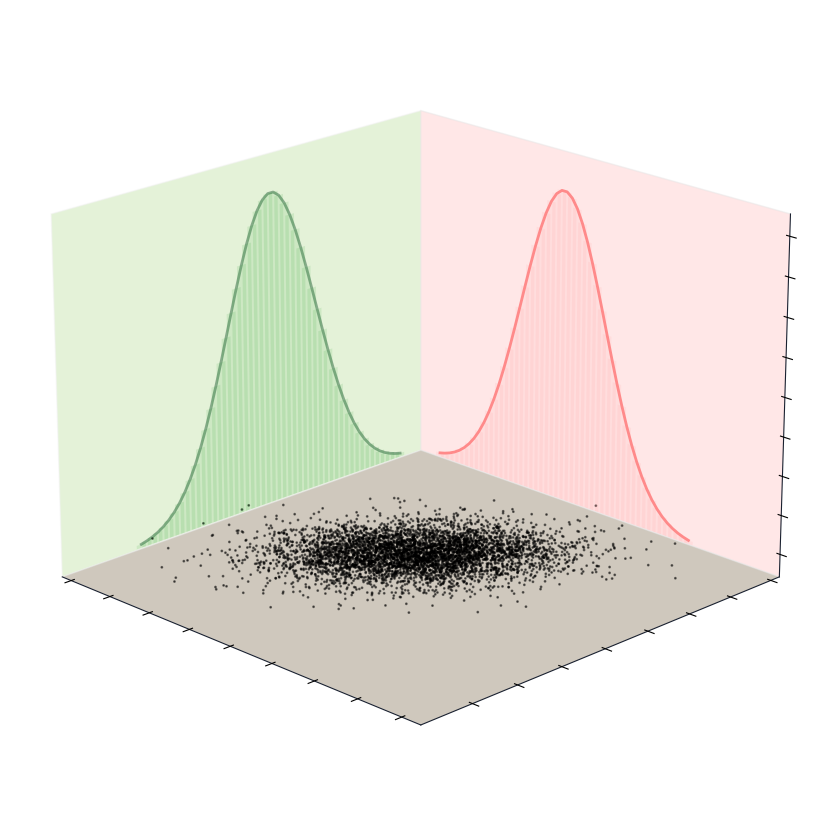

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 创建数据
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]
x, y = np.random.multivariate_normal(mean, cov, 5000).T

# 创建边缘分布数据
x_marginal = np.linspace(-3, 3, 50)
y_marginal = np.linspace(-3, 3, 50)
x_pdf = norm.pdf(x_marginal, loc=0, scale=1)
y_pdf = norm.pdf(y_marginal, loc=0, scale=1) 

# 创建图形
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制联合分布散点图
ax.scatter(x, y, np.zeros_like(x), color='black', s=1, alpha=0.5)

# 绘制边缘分布的柱状图
ax.bar(x_marginal, x_pdf, zs=-3.5, zdir='y', width=0.2, color='#FF8A8A', alpha=0.1)
ax.bar(y_marginal, y_pdf, zs=3.5, zdir='x', width=0.2, color='#059212', alpha=0.1)

# 绘制边缘分布曲线
ax.plot(x_marginal, np.full_like(x_marginal, -3.5), x_pdf, color='#FF8A8A', lw=2)
ax.plot(np.full_like(y_marginal, 3.5), y_marginal, y_pdf, color='#86AB89', lw=2)

# 设置标签
# ax.text(-2.5, -3.5, 0.15, 'Marginal\ndistribution #1', color='red', fontsize=10)
# ax.text(3.5, 2.5, 0.15, 'Marginal\ndistribution #2', color='blue', fontsize=10)
# ax.text(0, 0, -0.05, 'Joint\ndistribution', color='green', fontsize=10)

# 设置坐标平面的颜色
ax.xaxis.pane.set_facecolor('#CAE6B2')  # X坐标平面颜色
ax.yaxis.pane.set_facecolor('#FFD0D0')  # Y坐标平面颜色
ax.zaxis.pane.set_facecolor('#A0937D')  # Z坐标平面颜色

# 设置网格的颜色
ax.xaxis._axinfo['grid']['color'] = "black"
ax.yaxis._axinfo['grid']['color'] = "black"
ax.zaxis._axinfo['grid']['color'] = "black"

# 设置坐标轴线条的颜色
ax.xaxis.line.set_color("#1A2130")
ax.yaxis.line.set_color("#1A2130")
ax.zaxis.line.set_color("#1A2130")

# 隐藏网格和坐标平面
# ax.xaxis.pane.fill = False
# ax.yaxis.pane.fill = False
# ax.zaxis.pane.fill = False
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.grid(False)

# 调整视角
ax.view_init(20, 135)

# 美化图形
# ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
# 保存图像，背景透明，去除多余空白
plt.savefig('3d_distribution.png', transparent=True, bbox_inches='tight', pad_inches=0)

plt.show()

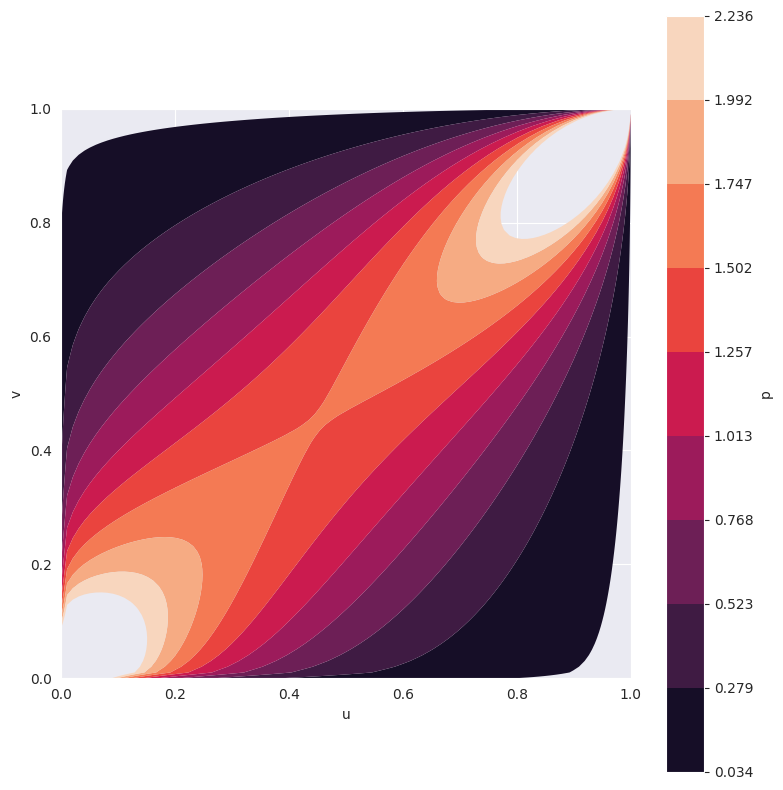

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

sns.set_style("darkgrid")
sns.mpl.rc("figure", figsize=(8, 8))

from statsmodels.distributions.copula.api import (
    CopulaDistribution, GumbelCopula, IndependenceCopula)

copula = GumbelCopula(theta=2)
_ = copula.plot_pdf()  # returns a matplotlib figure